# Community Detection — ANGEL (Overlapping)

**Research network:** UniPi publication graph (2020 snapshot)
**Goal:** Identify *overlapping* communities — papers that genuinely bridge multiple research areas.

---

## ANGEL-specific design choices

| Choice | Value | Rationale |
|---|---|---|
| **Algorithm** | ANGEL (Rossetti et al., 2017) | Only algorithm here producing **overlapping** communities |
| **G_internal** | Undirected projection | ANGEL builds ego-networks; edge direction is irrelevant |
| **G_combined** | Undirected + `weight` | BC edges are symmetric |
| **Threshold** | 0.55 | Justified by parameter sweep (§3) |
| **`min_community_size`** | 5 | Eliminates micro-clusters; justified by sensitivity analysis (§3) |
| **No ensemble** | — | ANGEL exposes no seed parameter; `PYTHONHASHSEED=0` for best-effort reproducibility |
| **Quality metric** | Modularity Overlap (OEC) | Newman-Girvan is undefined for overlapping partitions |

In [1]:
import os, re, time, pickle, textwrap, warnings
os.environ['PYTHONHASHSEED'] = '0'
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from cdlib import algorithms, NodeClustering, evaluation

GRAPH_DIR     = '../00_graph_construction/output/graphs'
INTERNAL_PATH = os.path.join(GRAPH_DIR, 'graph_internal_2020.gpickle')
COMBINED_PATH = os.path.join(GRAPH_DIR, 'graph_combined_2020.gpickle')

THRESHOLD     = 0.55
MIN_COMM_SIZE = 5
TOP_N_COMMS   = 20
TOP_K         = 5

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}


## 1. Graph Loading

In [2]:
def load_graph(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

G_internal = load_graph(INTERNAL_PATH)
G_combined = load_graph(COMBINED_PATH)
G_internal_undir = G_internal.to_undirected()

for u, v, d in G_combined.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_combined.edges(data=True)]

print(f"G_internal   {G_internal.number_of_nodes():>7,} nodes   {G_internal.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_combined   {G_combined.number_of_nodes():>7,} nodes   {G_combined.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}")

G_internal    55,078 nodes    217,925 edges  (directed, unweighted)
G_combined    58,627 nodes    590,157 edges  (undirected, weighted)  median_w=0.249


## 2. Attribute Statistics & Shared Helpers

In [3]:
# ===========================================================================
# FOS / SDG label parsing (shared across all CD notebooks)
# ===========================================================================
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),
    'sub':   re.compile(r'^\d{4}\s'),
}

def parse_labels(val, level='sub'):
    """Split semicolon-separated FOS/SDG string into atomic labels."""
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

# ===========================================================================
# Attribute statistics
# ===========================================================================
def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))
    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

s_int  = compute_attr_stats(G_internal)
s_comb = compute_attr_stats(G_combined)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv('FOS_stats.csv', index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv('SDG_stats.csv', index=False)

print(f"FOS nodes — G_internal: {s_int['FOS']['n_nodes']:,}  G_combined: {s_comb['FOS']['n_nodes']:,}")
print(f"SDG nodes — G_internal: {s_int['SDG']['n_nodes']:,}  G_combined: {s_comb['SDG']['n_nodes']:,}")

FOS nodes — G_internal: 43,128  G_combined: 44,958
SDG nodes — G_internal: 29,307  G_combined: 30,876


## 3. Threshold Selection — Elbow Sweep

ANGEL's `threshold` parameter controls how aggressively ego-networks are merged. Lower threshold → fewer, larger communities with less overlap. Higher → more, smaller communities with more overlap.

We sweep threshold × min_community_size and cache results (~6h total). The elbow in overlap rate guides the threshold choice.

In [ ]:
# ===========================================================================
# Elbow sweep — single CSV cache, extended metrics
# ===========================================================================
ELBOW_CSV = 'angel_elbow_sweep.csv'
THRESHOLDS_SWEEP = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
MIN_SIZES = list(range(2, 10))
N_WORKERS = 8


def _sweep_worker(args):
    """Run ANGEL for one (threshold, min_size) pair on both graphs."""
    int_path, comb_path, thr, min_size = args
    import pickle, time, numpy as np
    from collections import Counter
    from cdlib import algorithms, evaluation

    def _metrics(cl, G, all_nodes):
        mem = Counter(n for c in cl.communities for n in c)
        covered = set(mem)
        overlapping = {n for n, k in mem.items() if k > 1}
        sizes = [len(c) for c in cl.communities]

        # Avg memberships per overlapping node
        avg_memberships = (np.mean([mem[n] for n in overlapping])
                          if overlapping else 0.0)

        # Modularity overlap + conductance (quality metrics)
        mod_ol = evaluation.modularity_overlap(G, cl).score
        cond = evaluation.conductance(G, cl).score

        # Micro-community fraction (< 5 nodes)
        micro_frac = sum(1 for s in sizes if s < 5) / len(sizes) if sizes else 0.0

        return {
            'n_communities': len(cl.communities),
            'coverage': len(covered) / len(all_nodes) if all_nodes else 0.0,
            'overlap_rate': len(overlapping) / len(covered) if covered else 0.0,
            'n_overlapping': len(overlapping),
            'avg_memberships': avg_memberships,
            'avg_comm_size': float(np.mean(sizes)) if sizes else 0.0,
            'median_comm_size': float(np.median(sizes)) if sizes else 0.0,
            'modularity_overlap': mod_ol,
            'conductance': cond,
            'micro_frac': micro_frac,
        }

    with open(int_path, 'rb') as f:
        G_int = pickle.load(f).to_undirected()
    with open(comb_path, 'rb') as f:
        G_comb = pickle.load(f)

    records = []
    for G, gname in [(G_int, 'G_internal'), (G_comb, 'G_combined')]:
        t0 = time.time()
        cl = algorithms.angel(G, threshold=thr, min_community_size=min_size)
        m = _metrics(cl, G, set(G.nodes))
        records.append({
            'graph': gname, 'min_size': min_size, 'threshold': thr,
            **m, 'elapsed_s': round(time.time() - t0, 1)
        })
    return records


# --- Run or load ---
if os.path.exists(ELBOW_CSV):
    df_sweep = pd.read_csv(ELBOW_CSV)
    df_sweep = df_sweep.sort_values(['graph', 'min_size', 'threshold']).reset_index(drop=True)
    print(f"Loaded {len(df_sweep)} records from {ELBOW_CSV}")
else:
    args_list = [(INTERNAL_PATH, COMBINED_PATH, thr, ms)
                 for ms in MIN_SIZES for thr in THRESHOLDS_SWEEP]

    print(f"Running {len(args_list)} tasks ({len(THRESHOLDS_SWEEP)} thresholds "
          f"x {len(MIN_SIZES)} min_sizes x 2 graphs) ...")

    all_records = []
    with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(_sweep_worker, a): a for a in args_list}
        for i, fut in enumerate(as_completed(futures), 1):
            all_records.extend(fut.result())
            if i % 10 == 0:
                print(f"  {i}/{len(args_list)} done")

    df_sweep = pd.DataFrame(all_records)
    df_sweep.to_csv(ELBOW_CSV, index=False)
    print(f"Saved {len(df_sweep)} records to {ELBOW_CSV}")

Running 72 tasks (9 thresholds x 8 min_sizes x 2 graphs) ...
  10/72 done
  20/72 done
  30/72 done
  40/72 done
  50/72 done
  60/72 done


### Parameter Selection: threshold = 0.55, min_community_size = 5

ANGEL's behavior is governed by two parameters: `threshold` (how aggressively ego-networks are merged) and `min_community_size` (minimum nodes to form a community). We justify both through a systematic sweep over 9 thresholds × 8 min_sizes, totaling 144 configurations per graph.

#### Threshold selection

The sweep reveals three distinct regimes:

- **Low overlap (0.40–0.50):** Overlap rate <17%, modularity overlap ~0.18. Communities are nearly crisp — ANGEL adds little over Leiden/InfoMap. Bridge analysis is underpowered.
- **Balanced (0.50–0.60):** Overlap rate reaches 13–20%, modularity stays above 0.15, conductance is controlled. Enough overlap for bridge detection without degrading community quality.
- **Fragmentation (≥0.60):** Community count jumps +40%, modularity drops 43% (0.157 → 0.090 internal), conductance spikes by +0.10. Communities degrade rapidly.

The critical transition sits between 0.55 and 0.60: modularity drops 43% on G_internal (0.157 → 0.090) and 34% on G_combined (0.186 → 0.123), while conductance jumps by +0.10 on both graphs. The overlap gain for this cost is only +4–7 percentage points. We select **threshold = 0.55**, the last stable point before degradation:

| Metric | G_internal | G_combined |
|---|---|---|
| Communities | 1,574 | 1,456 |
| Coverage | 60.1% | 75.7% |
| Overlap rate | 12.6% | 19.8% |
| Modularity overlap | 0.157 | 0.186 |
| Conductance | 0.385 | 0.391 |
| Micro-community fraction | 0% | 0% |

#### min_community_size selection

At `min_size=3` (ANGEL default), ~20% of communities are micro-clusters with fewer than 5 nodes. These inflate community counts and overlap modularity without carrying structural meaning.

At **`min_size=5`**, micro-community fraction drops to zero. Coverage decreases marginally (69% → 60% internal, 81% → 76% combined), but every surviving community is backed by a non-trivial ego-network. Sensitivity analysis confirms stability: all metrics vary smoothly between min_size 4 and 6.

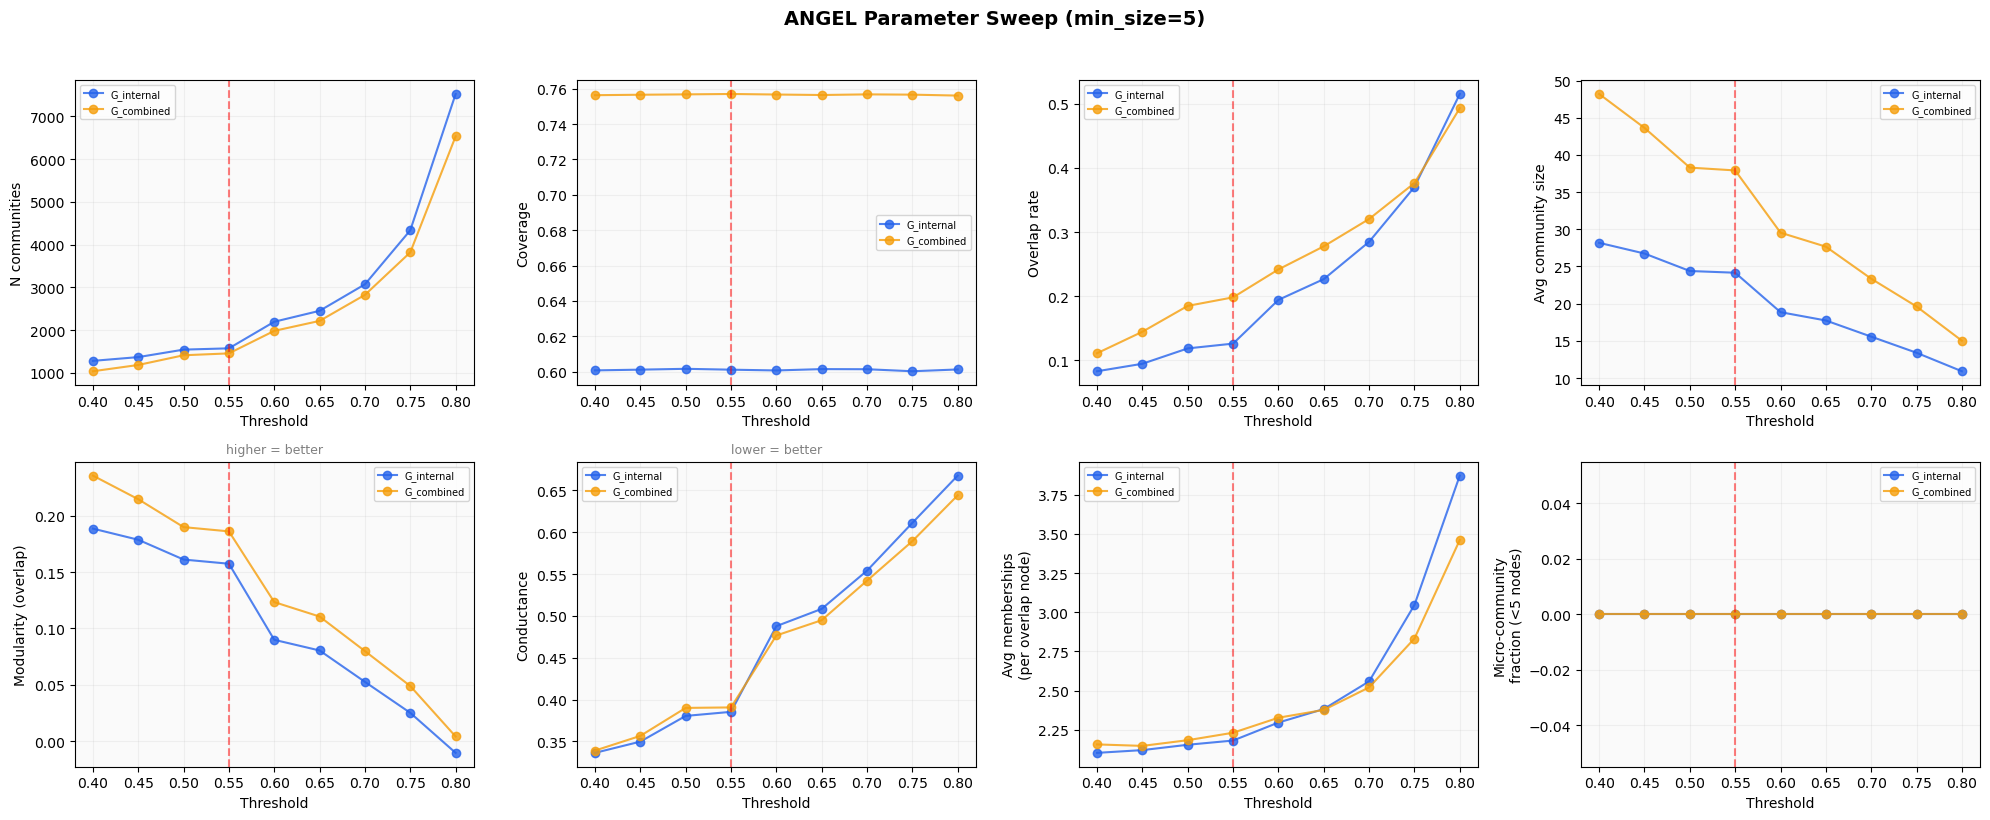


Metrics at threshold=0.55, min_size=5:
     graph  min_size  threshold  n_communities  coverage  overlap_rate  n_overlapping  avg_memberships  avg_comm_size  median_comm_size  modularity_overlap  conductance  micro_frac  elapsed_s
G_combined         5     0.5500           1456    0.7570        0.1980           8787           2.2318        37.9135           12.0000              0.1860       0.3907      0.0000   262.1000
G_internal         5     0.5500           1574    0.6011        0.1258           4164           2.1820        24.1595           10.0000              0.1574       0.3854      0.0000    16.4000


In [5]:
# ===========================================================================
# Elbow plots — structural + quality metrics
# ===========================================================================
ms = MIN_COMM_SIZE

metrics = [
    ('n_communities',      'N communities',         None),
    ('coverage',           'Coverage',              None),
    ('overlap_rate',       'Overlap rate',           None),
    ('avg_comm_size',      'Avg community size',     None),
    ('modularity_overlap', 'Modularity (overlap)',   'higher = better'),
    ('conductance',        'Conductance',            'lower = better'),
    ('avg_memberships',    'Avg memberships\n(per overlap node)', None),
    ('micro_frac',         'Micro-community\nfraction (<5 nodes)', None),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'ANGEL Parameter Sweep (min_size={ms})', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, ylabel, note) in zip(axes.ravel(), metrics):
    for gname, color in [('G_internal', '#2563EB'), ('G_combined', '#F59E0B')]:
        sub = df_sweep[(df_sweep['graph'] == gname) & (df_sweep['min_size'] == ms)]
        ax.plot(sub['threshold'], sub[col], 'o-', color=color, label=gname, alpha=0.8)
    ax.axvline(THRESHOLD, ls='--', color='red', alpha=0.5)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(ylabel)
    if note:
        ax.set_title(note, fontsize=9, color='grey')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

print(f"\nMetrics at threshold={THRESHOLD}, min_size={ms}:")
chosen = df_sweep[(df_sweep['threshold'] == THRESHOLD) & (df_sweep['min_size'] == ms)]
print(chosen.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

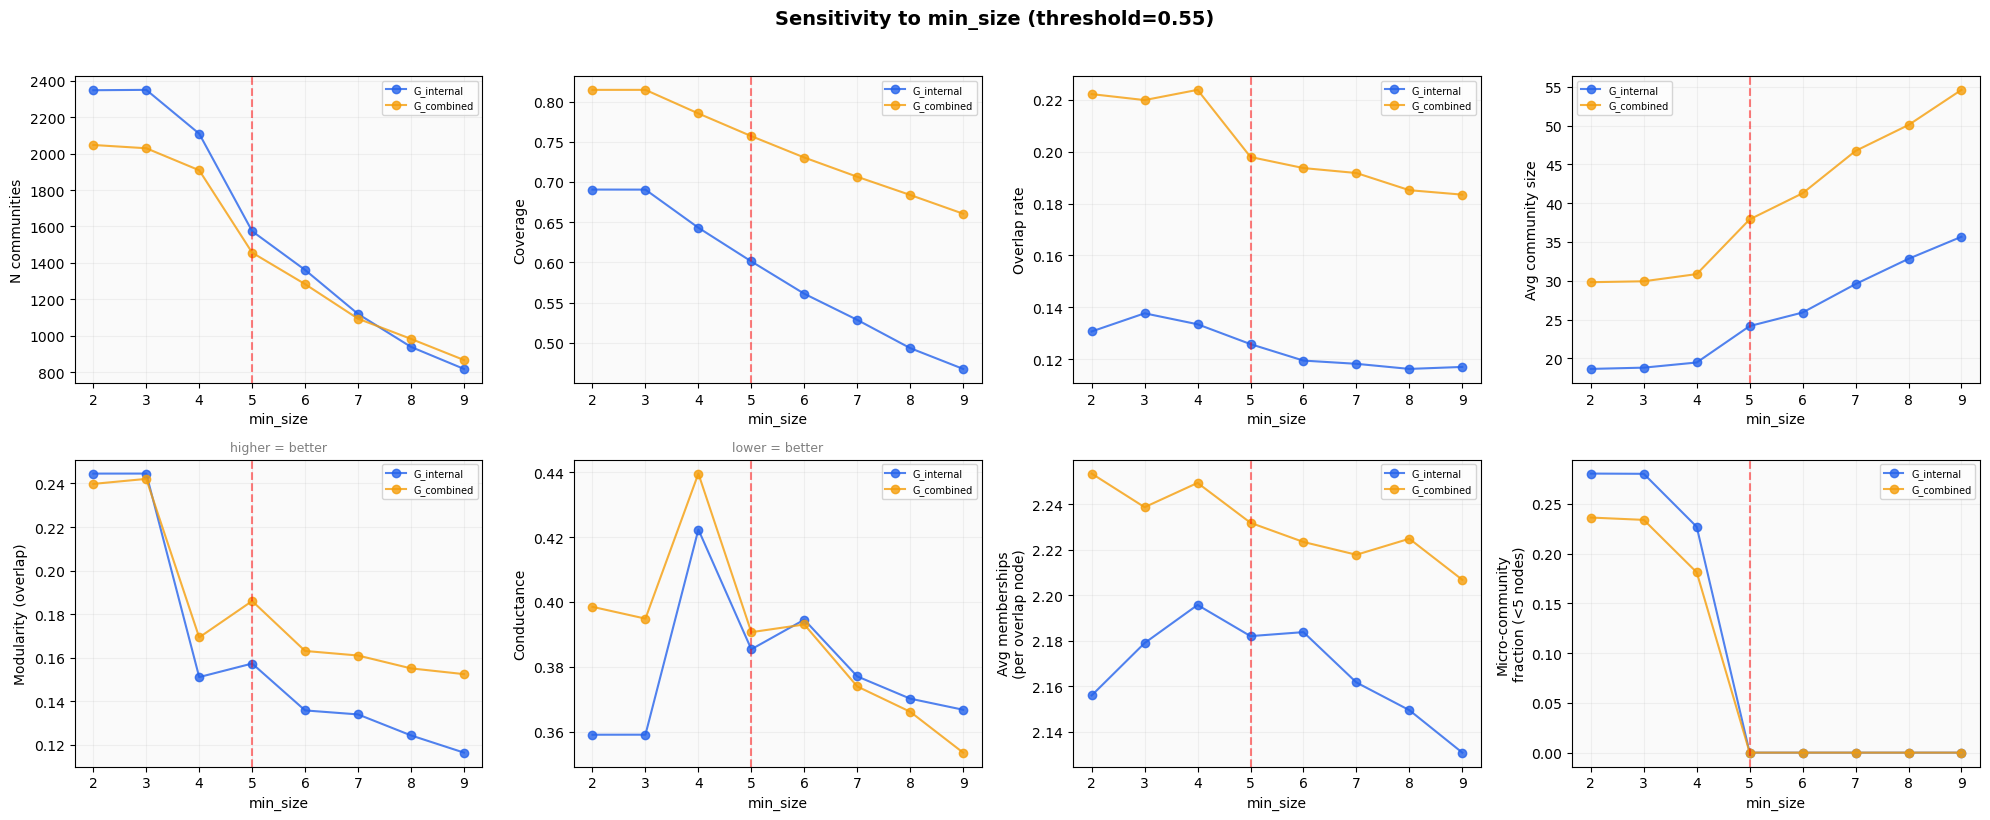

In [6]:
# ===========================================================================
# Min_size sensitivity at chosen threshold
# ===========================================================================
thr = THRESHOLD

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'Sensitivity to min_size (threshold={thr})', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, ylabel, note) in zip(axes.ravel(), metrics):
    for gname, color in [('G_internal', '#2563EB'), ('G_combined', '#F59E0B')]:
        sub = df_sweep[(df_sweep['graph'] == gname) & (df_sweep['threshold'] == thr)].sort_values('min_size')
        ax.plot(sub['min_size'], sub[col], 'o-', color=color, label=gname, alpha=0.8)
    ax.axvline(MIN_COMM_SIZE, ls='--', color='red', alpha=0.5)
    ax.set_xlabel('min_size')
    ax.set_ylabel(ylabel)
    if note:
        ax.set_title(note, fontsize=9, color='grey')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

## 4. ANGEL Runs

In [57]:
# ===========================================================================
# ANGEL run wrapper
# ===========================================================================
def angel_coverage_stats(cl, all_nodes):
    """Coverage and overlap statistics for an ANGEL NodeClustering."""
    membership = Counter(node for comm in cl.communities for node in comm)
    covered = set(membership)
    overlapping = {n for n, cnt in membership.items() if cnt > 1}
    return {
        'coverage': len(covered) / len(all_nodes) if all_nodes else 0.0,
        'overlap_rate': len(overlapping) / len(covered) if covered else 0.0,
        'n_communities': len(cl.communities),
        'n_overlapping': len(overlapping),
    }

def run_angel(G, graph_name, threshold=THRESHOLD, min_community_size=MIN_COMM_SIZE):
    """Run ANGEL once and return (NodeClustering, stats dict)."""
    t0 = time.time()
    all_nodes = set(G.nodes)
    print(f'--- ANGEL run: {graph_name} ---')
    print(f'    threshold={threshold}  min_size={min_community_size}')

    cl = algorithms.angel(G, threshold=threshold, min_community_size=min_community_size)
    cov = angel_coverage_stats(cl, all_nodes)
    mod_ol = evaluation.modularity_overlap(G, cl).score
    cond = evaluation.conductance(G, cl).score

    stats = {**cov, 'mod_overlap': mod_ol, 'conductance': cond}

    print(f'    Communities : {cov["n_communities"]:,}')
    print(f'    Coverage    : {cov["coverage"]:.2%}')
    print(f'    Overlap rate: {cov["overlap_rate"]:.2%}  ({cov["n_overlapping"]:,} nodes in >=2 comms)')
    print(f'    Mod. overlap: {mod_ol:.4f}')
    print(f'    Conductance : {cond:.4f}')
    print(f'    Elapsed     : {time.time()-t0:.1f}s\n')

    return cl, stats

In [58]:
angel_internal, angel_internal_stats = run_angel(
    G_internal_undir, 'G_internal undirected'
)

--- ANGEL run: G_internal undirected ---
    threshold=0.55  min_size=5
    Communities : 1,567
    Coverage    : 60.07%
    Overlap rate: 11.93%  (3,948 nodes in >=2 comms)
    Mod. overlap: 0.1610
    Conductance : 0.3826
    Elapsed     : 11.4s



In [59]:
angel_combined, angel_combined_stats = run_angel(
    G_combined, 'G_combined'
)

--- ANGEL run: G_combined ---
    threshold=0.55  min_size=5
    Communities : 1,453
    Coverage    : 75.61%
    Overlap rate: 21.70%  (9,617 nodes in >=2 comms)
    Mod. overlap: 0.1860
    Conductance : 0.3912
    Elapsed     : 172.1s



### 4.1 Coverage & Overlap Statistics

Unlike Leiden and InfoMap, ANGEL can leave nodes uncovered and assign nodes to multiple communities. These metrics are ANGEL-specific.

In [60]:
def print_coverage_comparison(stats_int, stats_comb):
    rows = []
    for stats, graph in [(stats_int, 'G_internal'), (stats_comb, 'G_combined')]:
        rows.append({'Graph': graph,
                     'Communities': stats['n_communities'],
                     'Coverage': f"{stats['coverage']:.1%}",
                     'Overlap rate': f"{stats['overlap_rate']:.1%}",
                     'Bridge nodes': stats['n_overlapping'],
                     'Mod. Overlap': f"{stats['mod_overlap']:.4f}",
                     'Conductance': f"{stats['conductance']:.4f}"})
    print(pd.DataFrame(rows).set_index('Graph').to_string())

print_coverage_comparison(angel_internal_stats, angel_combined_stats)

            Communities Coverage Overlap rate  Bridge nodes Mod. Overlap Conductance
Graph                                                                               
G_internal         1567    60.1%        11.9%          3948       0.1610      0.3826
G_combined         1453    75.6%        21.7%          9617       0.1860      0.3912


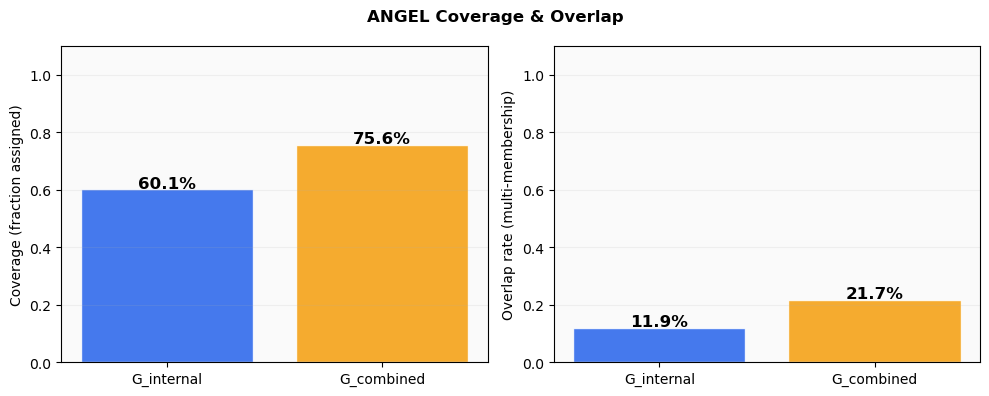

In [61]:
def plot_coverage_comparison(stats_int, stats_comb):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle('ANGEL Coverage & Overlap', fontsize=12, fontweight='bold')
    for ax, metric, ylabel in [
        (axes[0], 'coverage', 'Coverage (fraction assigned)'),
        (axes[1], 'overlap_rate', 'Overlap rate (multi-membership)'),
    ]:
        vals = [stats_int[metric], stats_comb[metric]]
        bars = ax.bar(['G_internal', 'G_combined'], vals,
                      color=['#2563EB', '#F59E0B'], edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.15)
        ax.set_facecolor('#FAFAFA')
    plt.tight_layout()
    plt.show()

plot_coverage_comparison(angel_internal_stats, angel_combined_stats)

**Observations:**
- **Coverage jumps** from 60.1% to 75.6%: BC edges connect previously isolated nodes into ego-networks.
- **Overlap rate nearly doubles** from 11.9% to 21.7%: BC creates more boundary nodes bridging multiple communities.
- **Bridge nodes** increase from 3,948 to 9,617 — BC more than doubles the number of structurally ambiguous papers.
- Both effects confirm BC's de-siloing role, seen here through ANGEL's unique overlap mechanism.

## 5. Semantic Profiles — FOS and SDG

In [62]:
def extract_semantic_topk(partition, G, attr='FOS', level='sub',
                          top_n=TOP_N_COMMS, top_k=TOP_K):
    """Top-K most frequent labels per community for the largest top_n communities."""
    communities = sorted(partition.communities, key=len, reverse=True)[:top_n]
    rows = []
    for rank, comm in enumerate(communities, 1):
        counter = Counter()
        for node in comm:
            counter.update(parse_labels(G.nodes[node].get(attr), level=level))
        total = sum(counter.values())
        top_terms = counter.most_common(top_k)
        top_terms += [('N/A', 0)] * (top_k - len(top_terms))
        for pos, (term, cnt) in enumerate(top_terms, 1):
            rows.append({
                'CommunityRank': rank, 'CommunitySize': len(comm),
                'Position': pos, 'Term': term,
                'Count': cnt, 'Share': cnt / total if total else 0,
            })
    return pd.DataFrame(rows)


def plot_semantic_topk(df_int, df_comb, semantic_name='FOS', cmap='YlGnBu'):
    """Side-by-side heatmap of top-K labels per community."""
    top_k = int(df_int['Position'].max())

    def _build_matrix(df):
        comms = sorted(df['CommunityRank'].unique())
        val_mat = np.zeros((len(comms), top_k))
        lbl_mat = [['' for _ in range(top_k)] for _ in range(len(comms))]
        ylabels = []
        for i, c in enumerate(comms):
            rows = df[df['CommunityRank'] == c].sort_values('Position')
            ylabels.append(f"C{c} (n={int(rows['CommunitySize'].iloc[0])})")
            for _, r in rows.iterrows():
                j = int(r['Position']) - 1
                val_mat[i, j] = r['Share']
                term = textwrap.shorten(str(r['Term']), width=24, placeholder='...')
                lbl_mat[i][j] = f"{term}\n{int(r['Count'])} ({r['Share']*100:.1f}%)"
        return val_mat, lbl_mat, ylabels

    mat_i, lbl_i, y_i = _build_matrix(df_int)
    mat_c, lbl_c, y_c = _build_matrix(df_comb)
    vmax = max(mat_i.max(), mat_c.max(), 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    for ax, mat, lbls, ylabs, title in [
        (axes[0], mat_i, lbl_i, y_i, f'ANGEL {semantic_name} — G_internal'),
        (axes[1], mat_c, lbl_c, y_c, f'ANGEL {semantic_name} — G_combined'),
    ]:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xticks(range(top_k))
        ax.set_xticklabels([f'Top {i+1}' for i in range(top_k)])
        ax.set_yticks(range(len(ylabs)))
        ax.set_yticklabels(ylabs, fontsize=9)
        ax.set_xlabel('Label rank within community')
        ax.set_ylabel('Community')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, lbls[i][j], ha='center', va='center',
                        fontsize=7.5, color='black')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9,
                 label='Label share within community')
    plt.show()

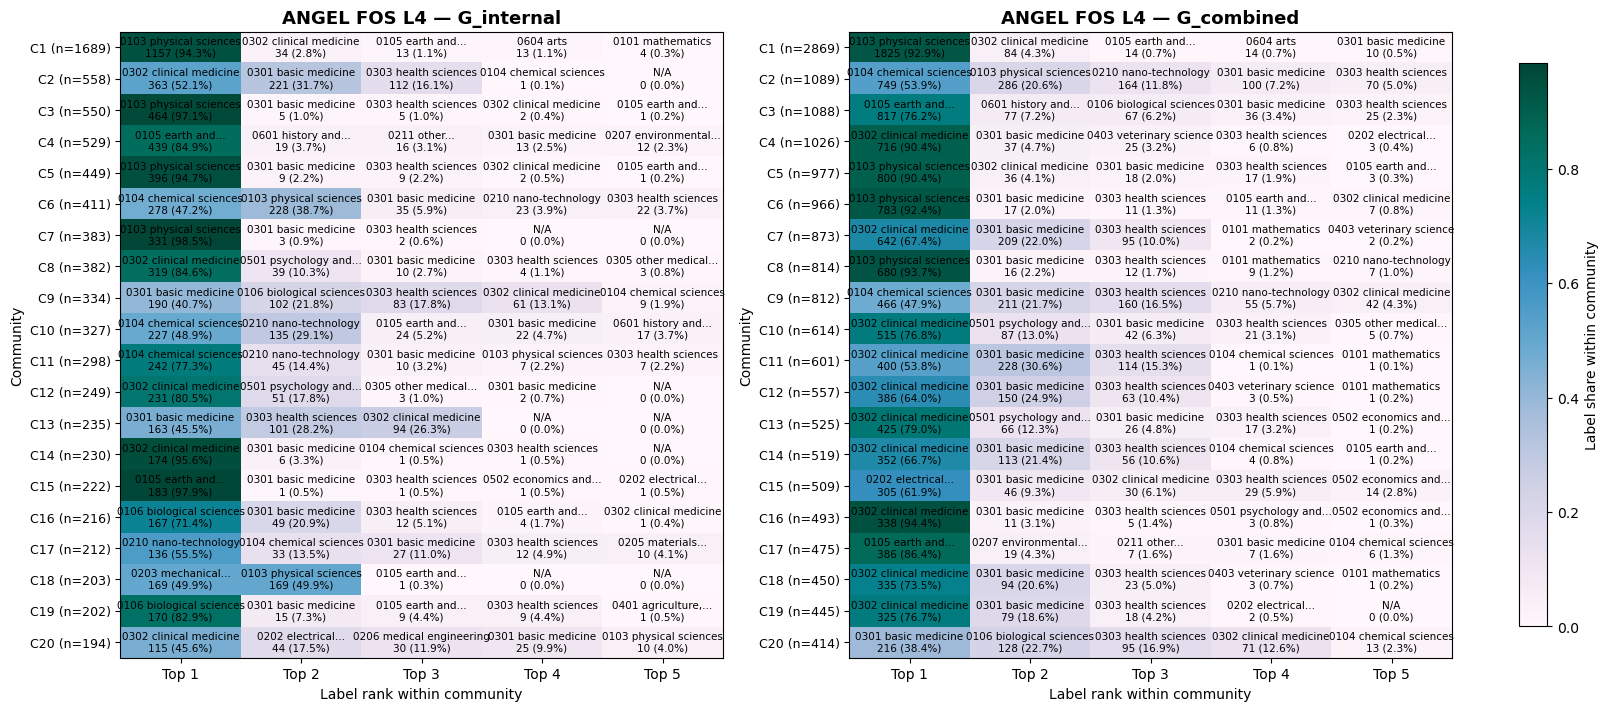

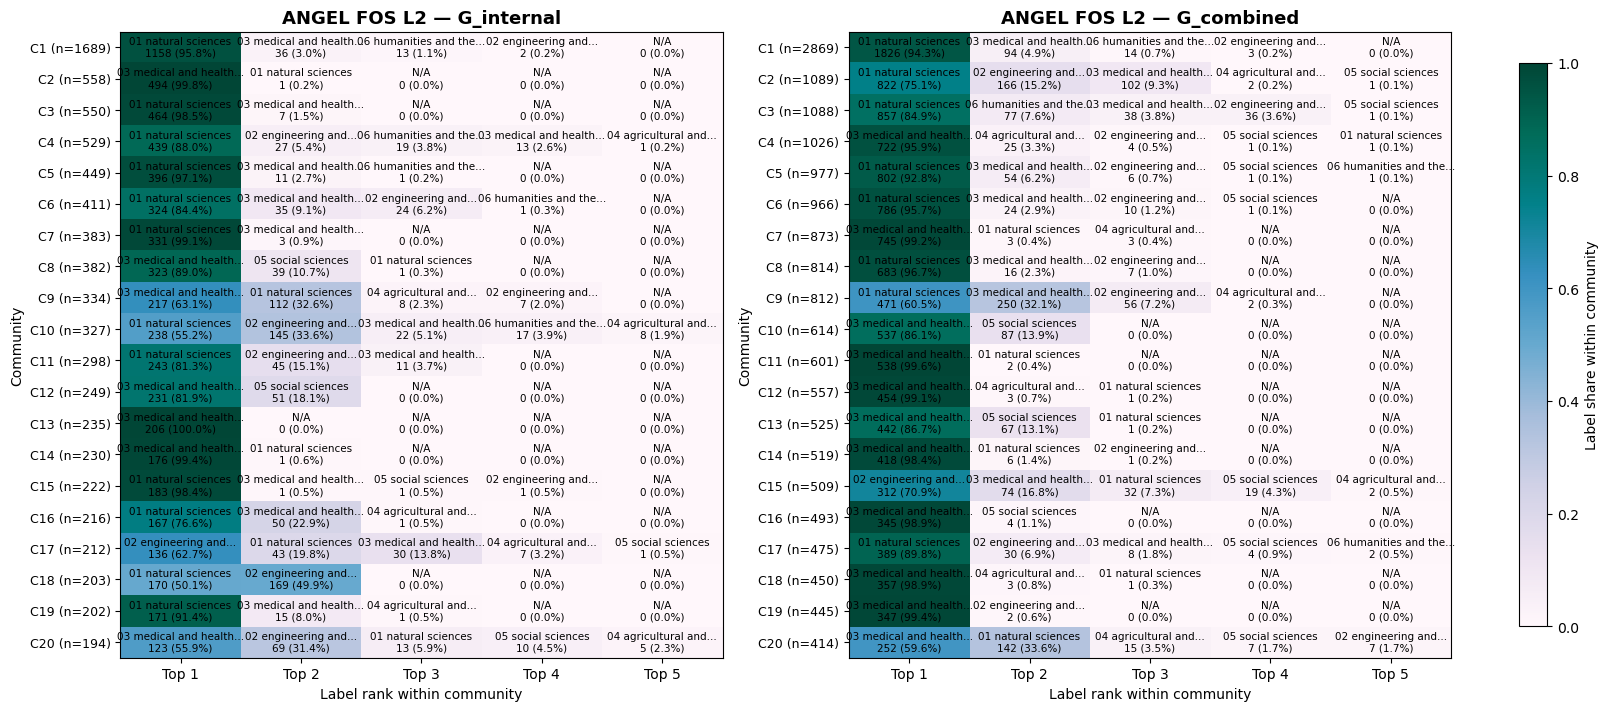

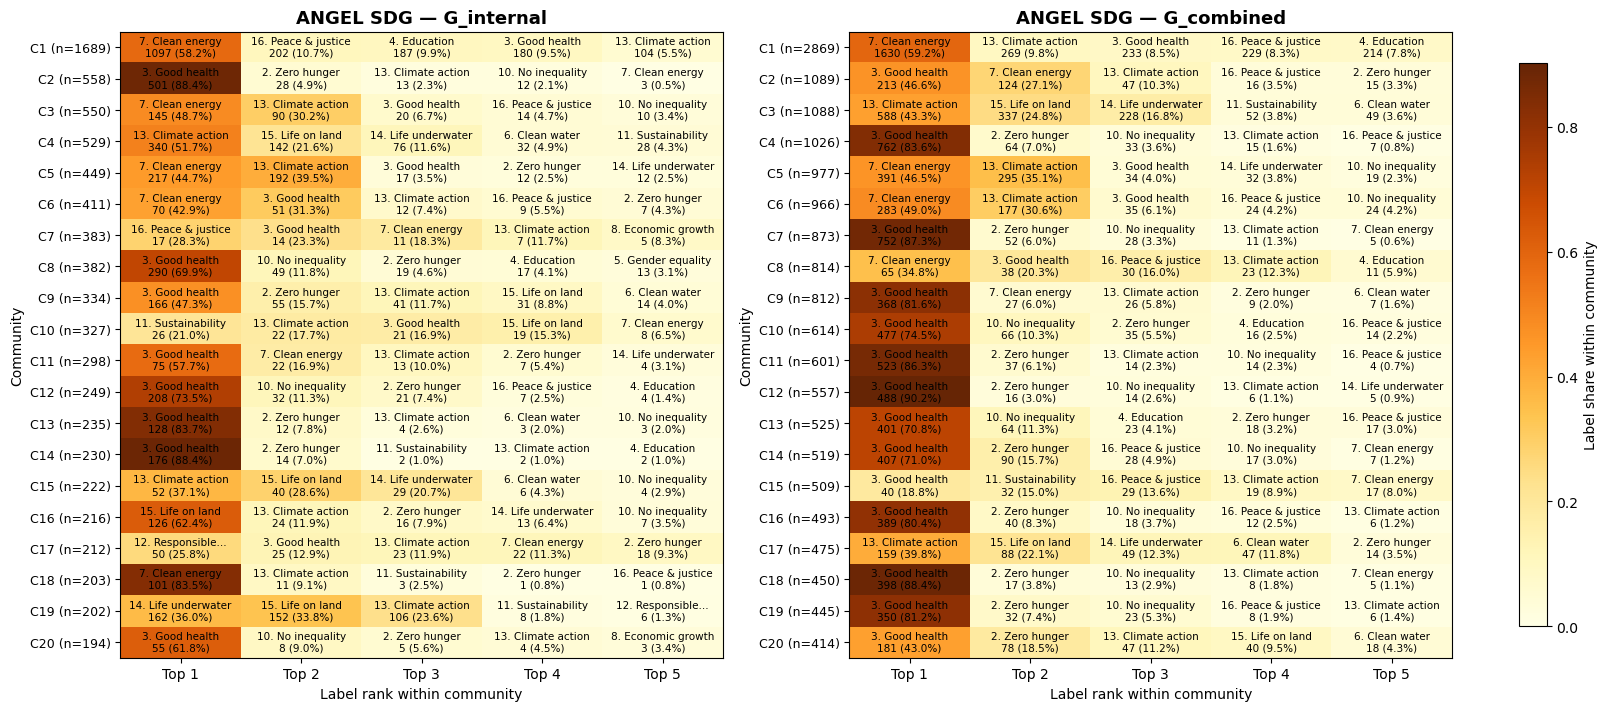

In [ ]:
# FOS sub-discipline (4-digit)
df_fos_int  = extract_semantic_topk(angel_internal, G_internal_undir, attr='FOS', level='sub')
df_fos_comb = extract_semantic_topk(angel_combined, G_combined,       attr='FOS', level='sub')

# FOS macro-discipline (2-digit)
df_fos_l2_int  = extract_semantic_topk(angel_internal, G_internal_undir, attr='FOS', level='macro')
df_fos_l2_comb = extract_semantic_topk(angel_combined, G_combined,       attr='FOS', level='macro')

# SDG
df_sdg_int  = extract_semantic_topk(angel_internal, G_internal_undir, attr='SDG', level='all')
df_sdg_comb = extract_semantic_topk(angel_combined, G_combined,       attr='SDG', level='all')

# plot_semantic_topk(df_fos_int, df_fos_comb, semantic_name='FOS L4', cmap='PuBuGn')
# plot_semantic_topk(df_fos_l2_int, df_fos_l2_comb, semantic_name='FOS L2', cmap='PuBuGn')
# plot_semantic_topk(df_sdg_int, df_sdg_comb, semantic_name='SDG', cmap='YlOrBr')

## 6. Size Distribution


ANGEL / Internal:
  Communities: 1567  |  Min/Max: 5/1689
  Mean: 24.1  |  Median: 10.0
  Top  10 cover 14.9%
  Top  50 cover 32.2%
  Top 100 cover 43.1%

ANGEL / Combined:
  Communities: 1453  |  Min/Max: 5/2869
  Mean: 38.8  |  Median: 12.0
  Top  10 cover 19.7%
  Top  50 cover 42.5%
  Top 100 cover 54.6%


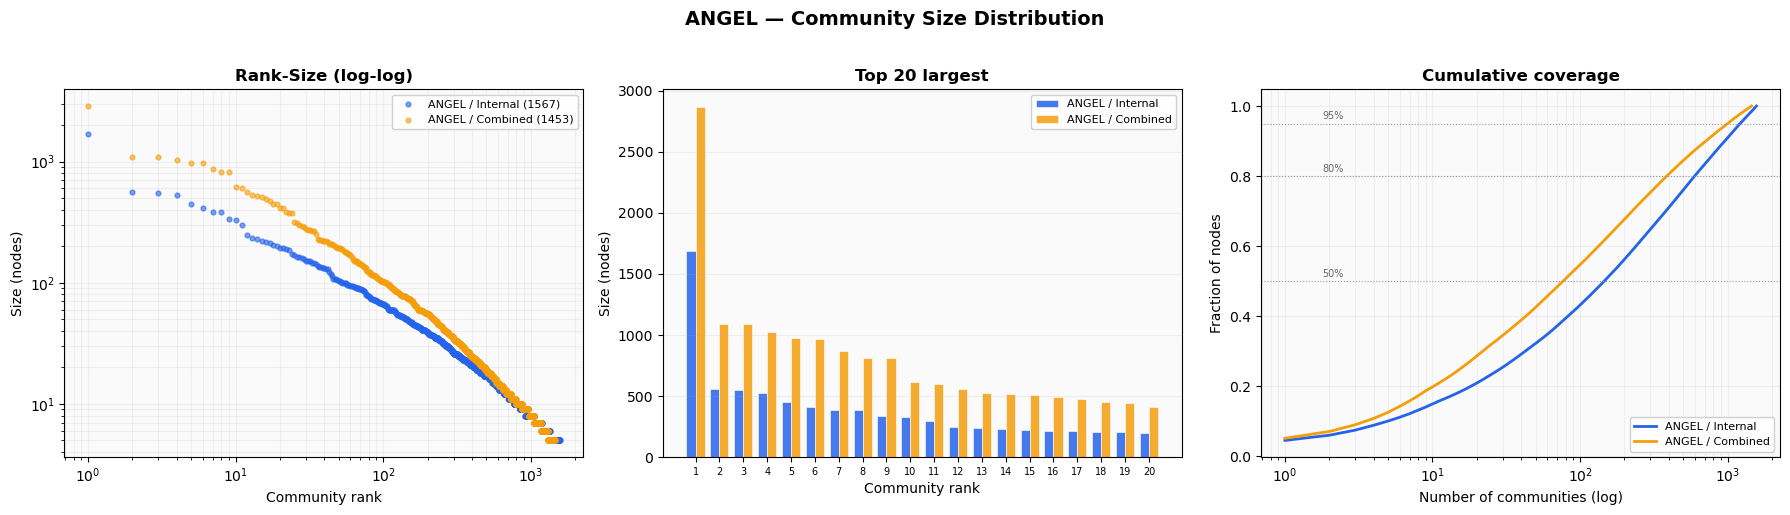

In [64]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B', title=''):
    """Three-panel size comparison + summary statistics."""
    sizes_a = sorted([len(c) for c in partition_a.communities], reverse=True)
    sizes_b = sorted([len(c) for c in partition_b.communities], reverse=True)

    for sizes, label in [(sizes_a, label_a), (sizes_b, label_b)]:
        arr = np.array(sizes)
        total = arr.sum()
        print(f"\n{label}:")
        print(f"  Communities: {len(arr)}  |  Min/Max: {arr.min()}/{arr.max()}")
        print(f"  Mean: {arr.mean():.1f}  |  Median: {np.median(arr):.1f}")
        for n in [10, 50, 100]:
            if n <= len(arr):
                print(f"  Top {n:3d} cover {sum(sizes[:n])/total:.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    ax = axes[0]
    ax.scatter(range(1, len(sizes_a)+1), sizes_a, s=12, alpha=0.6,
               color=color_a, label=f'{label_a} ({len(sizes_a)})', zorder=3)
    ax.scatter(range(1, len(sizes_b)+1), sizes_b, s=12, alpha=0.6,
               color=color_b, label=f'{label_b} ({len(sizes_b)})', zorder=3)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Community rank'); ax.set_ylabel('Size (nodes)')
    ax.set_title('Rank-Size (log-log)', fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.15, which='both')
    ax.set_facecolor('#FAFAFA')

    top_n = 20
    ax = axes[1]
    x = np.arange(top_n); w = 0.38
    y_a = sizes_a[:top_n] + [0] * max(0, top_n - len(sizes_a))
    y_b = sizes_b[:top_n] + [0] * max(0, top_n - len(sizes_b))
    ax.bar(x - w/2, y_a, w, color=color_a, alpha=0.85, label=label_a,
           edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, y_b, w, color=color_b, alpha=0.85, label=label_b,
           edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Community rank'); ax.set_ylabel('Size (nodes)')
    ax.set_title(f'Top {top_n} largest', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([str(i+1) for i in x], fontsize=7)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(axis='y', alpha=0.15)
    ax.set_facecolor('#FAFAFA')

    ax = axes[2]
    cov_a = np.cumsum(sizes_a) / sum(sizes_a)
    cov_b = np.cumsum(sizes_b) / sum(sizes_b)
    ax.plot(range(1, len(cov_a)+1), cov_a, color=color_a, lw=2, label=label_a)
    ax.plot(range(1, len(cov_b)+1), cov_b, color=color_b, lw=2, label=label_b)
    for thr in (0.50, 0.80, 0.95):
        ax.axhline(thr, ls=':', lw=0.8, color='#999')
        ax.text(1.8, thr + 0.012, f'{int(thr*100)}%', fontsize=7, color='#666')
    ax.set_xscale('log')
    ax.set_xlabel('Number of communities (log)'); ax.set_ylabel('Fraction of nodes')
    ax.set_title('Cumulative coverage', fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.15, which='both')
    ax.set_facecolor('#FAFAFA')

    plt.tight_layout()
    plt.show()

plot_size_distribution(
    angel_internal, 'ANGEL / Internal',
    angel_combined, 'ANGEL / Combined',
    title='ANGEL — Community Size Distribution'
)

## 7. Bridge Paper Analysis

A paper in ≥2 ANGEL communities is a **bridge candidate**. However, multi-membership can also arise as a structural artefact when dense hub ego-networks overlap without genuine interdisciplinarity.

We classify each bridge by **dominance**: the fraction of its neighbours in the most-represented community.

| Dominance | Classification |
|---|---|
| ≥ 85% | Likely artefact — neighbours skewed to one community |
| < 85% | True bridge — neighbours spread across communities |

In [65]:
def extract_overlapping_papers(angel_clustering):
    """Return {node: [comm_ids]} for nodes in >=2 communities."""
    node_to_comms = angel_clustering.to_node_community_map()
    return dict(sorted(
        {n: sorted(c) for n, c in node_to_comms.items() if len(c) > 1}.items(),
        key=lambda x: len(x[1]), reverse=True
    ))


def analyze_bridge_topology(top_candidates, angel_clustering, G):
    """Classify bridge papers: true bridge vs likely artefact."""
    comm_sets = [set(c) for c in angel_clustering.communities]
    rows = []
    for node_id, comm_ids in top_candidates:
        neighbours = set(G.neighbors(node_id))
        comm_neigh = {cid: len(neighbours & comm_sets[cid]) for cid in comm_ids}
        total_tracked = sum(comm_neigh.values())
        if total_tracked == 0:
            dominance, status = 100.0, 'Isolated'
        else:
            dominance = max(comm_neigh.values()) / total_tracked * 100
            status = 'Likely artefact (skewed)' if dominance > 85 else 'True bridge'

        node_data = G.nodes.get(node_id, {})
        fos = parse_labels(node_data.get('FOS'), level='sub')
        title = node_data.get('mainTitle', 'N/A')

        rows.append({
            'Node ID': node_id, 'Num Comms': len(comm_ids),
            'Total Degree': len(neighbours), 'Dominance %': round(dominance, 1),
            'Classification': status,
            'FOS': ', '.join(fos[:3]) if fos else 'N/A',
            'Title': title[:80] if title else 'N/A',
        })
    return pd.DataFrame(rows)


overlapping_int  = extract_overlapping_papers(angel_internal)
overlapping_comb = extract_overlapping_papers(angel_combined)
print(f"Bridge papers — G_internal : {len(overlapping_int):,}")
print(f"Bridge papers — G_combined : {len(overlapping_comb):,}")

Bridge papers — G_internal : 3,948
Bridge papers — G_combined : 9,617


In [66]:
# Top-30 bridge candidates
top_bridges_int  = list(overlapping_int.items())[:30]
top_bridges_comb = list(overlapping_comb.items())[:30]

df_bridges_int  = analyze_bridge_topology(top_bridges_int,  angel_internal, G_internal_undir)
df_bridges_comb = analyze_bridge_topology(top_bridges_comb, angel_combined, G_combined)

print('=== Top bridge papers — G_internal ===')
print(df_bridges_int[['Node ID','Num Comms','Total Degree','Dominance %','Classification','FOS']].head(15).to_string())
print('\n=== Top bridge papers — G_combined ===')
print(df_bridges_comb[['Node ID','Num Comms','Total Degree','Dominance %','Classification','FOS']].head(15).to_string())

=== Top bridge papers — G_internal ===
                                           Node ID  Num Comms  Total Degree  Dominance %            Classification                                                                           FOS
0   doi_dedup___::55c5c0e747a5db2bc50792bb3ff252fa          8            59         17.1               True bridge                                     0301 basic medicine, 0303 health sciences
1   doi_dedup___::d4703e4def6bab6820e7feea977a3b99          7           429         91.6  Likely artefact (skewed)                                                        0103 physical sciences
2   doi_dedup___::947fa7fbe0cbd18cba738da995e09d86          7            35         32.7               True bridge                                   0301 basic medicine, 0302 clinical medicine
3   doi_dedup___::beaf44e628247ff8aa08651b0ab25803          6            26         31.9               True bridge                                                        0302 clinical medic

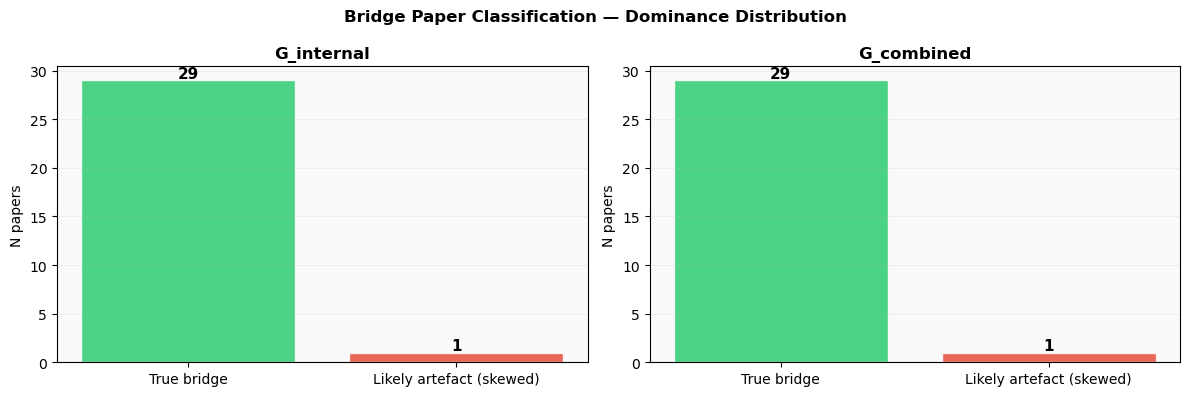

In [67]:
# Bridge classification plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bridge Paper Classification — Dominance Distribution',
             fontsize=12, fontweight='bold')
for ax, df, title in [
    (axes[0], df_bridges_int,  'G_internal'),
    (axes[1], df_bridges_comb, 'G_combined'),
]:
    counts = df['Classification'].value_counts()
    colors = ['#e74c3c' if 'artefact' in k else
              '#2ecc71' if 'True' in k else '#95a5a6' for k in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('N papers')
    ax.grid(axis='y', alpha=0.15)
    ax.set_facecolor('#FAFAFA')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Crisp Projection & Fate Analysis

To compare ANGEL with crisp algorithms and perform fate analysis, we project the overlapping partition to a disjoint one: each multi-community node is assigned to the community where it has the most neighbours.

In [68]:
def crisp_assignment(graph, clustering):
    """Convert overlapping to disjoint: assign each node to densest community."""
    comm_sets = [set(c) for c in clustering.communities]
    node_to_comms = clustering.to_node_community_map()
    final = {}
    for node, comms in node_to_comms.items():
        if len(comms) == 1:
            final[node] = comms[0]
        else:
            neighbours = set(graph.neighbors(node))
            final[node] = max(comms, key=lambda cid: len(neighbours & comm_sets[cid]))
    clean = defaultdict(list)
    for node, cid in final.items():
        clean[cid].append(node)
    return NodeClustering(list(clean.values()), graph=graph, method_name='angel_crisp')

angel_crisp_internal = crisp_assignment(G_internal_undir, angel_internal)
angel_crisp_combined = crisp_assignment(G_combined, angel_combined)
print(f'Crisp communities — G_internal: {len(angel_crisp_internal.communities):,}')
print(f'Crisp communities — G_combined: {len(angel_crisp_combined.communities):,}')

Crisp communities — G_internal: 1,556
Crisp communities — G_combined: 1,437


### 8.1 Fate Analysis — Internal → Combined

Same framework as Leiden/InfoMap: classify each crisp internal community by its fate in the crisp combined partition. Components ≥ 50 nodes only.

In [69]:
# ===========================================================================
# Partition comparison helpers + fate analysis
# ===========================================================================

def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}
        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue
        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)
    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    # Merge events
    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    # Global metrics
    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"█" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components >= 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = 'CROSS-DOMAIN' if ev['cross_domain'] else 'same domain'
        print(f'\n  [{i+1}] {tag}  --  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [70]:
# --- Run fate analysis ---
df_fates_angel, merge_events_angel, global_angel = classify_community_fates(
    part_a   = angel_crisp_internal,
    part_b   = angel_crisp_combined,
    G        = G_combined,
    name_a   = 'ANGEL_crisp/Internal',
    name_b   = 'ANGEL_crisp/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = 50,
)


  Fate Analysis: ANGEL_crisp/Internal -> ANGEL_crisp/Combined
  Communities analysed (>=50 nodes): 119
  NMI: 0.9447  |  VI: 0.4760
    dissolved       1  (  0.8%)  
    merged         20  ( 16.8%)  ████████
    partial        10  (  8.4%)  ████
    stable         88  ( 73.9%)  ████████████████████████████████████

  Merge events: 12  |  Cross-domain: 0


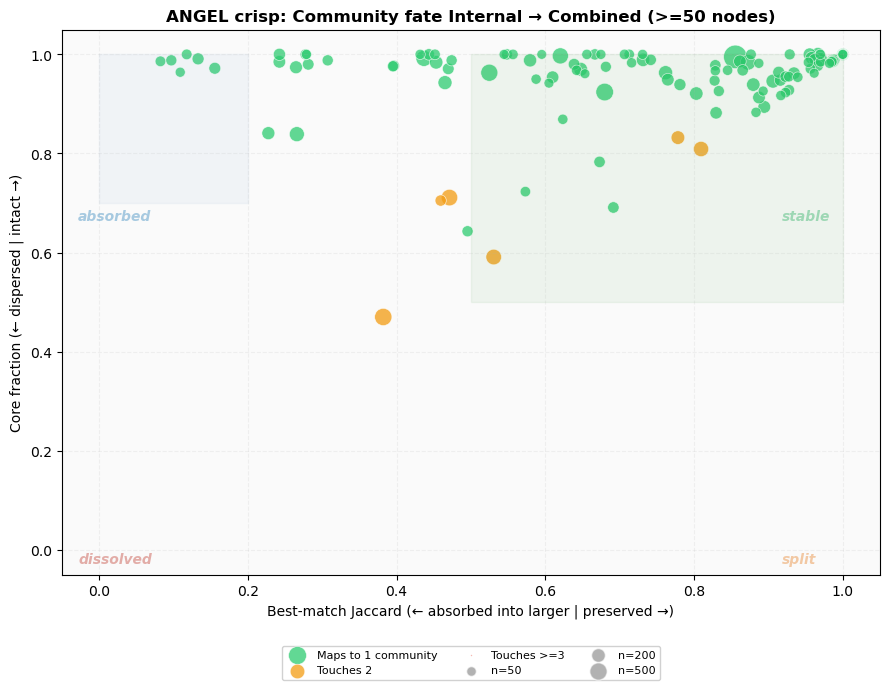

In [ ]:
# # --- Fate space scatter ---
# fig, ax = plt.subplots(figsize=(9, 7))

# palette = {1: '#2ecc71', 2: '#f39c12', 3: '#e74c3c'}
# labels  = {1: 'Maps to 1 community', 2: 'Touches 2', 3: 'Touches >=3'}
# n_touch = df_fates_angel['n_b_touched'].clip(upper=3)

# for n, color in palette.items():
#     mask = n_touch == n
#     ax.scatter(
#         df_fates_angel.loc[mask, 'best_jacc'],
#         df_fates_angel.loc[mask, 'top_b_frac'],
#         c=color, label=labels[n],
#         s=df_fates_angel.loc[mask, 'size_a'] ** 0.5 * 7,
#         alpha=0.75, edgecolors='white', linewidth=0.5,
#     )

# ax.fill_between([0.5, 1.0], 0.5, 1.0, alpha=0.05, color='green')
# ax.fill_between([0.0, 0.2], 0.7, 1.0, alpha=0.05, color='steelblue')

# kw = dict(fontsize=10, fontweight='bold', alpha=0.4, style='italic')
# ax.text(0.88, 0.65, 'stable',    color='#27ae60', transform=ax.transAxes, **kw)
# ax.text(0.02, 0.65, 'absorbed',  color='#2980b9', transform=ax.transAxes, **kw)
# ax.text(0.02, 0.02, 'dissolved', color='#c0392b', transform=ax.transAxes, **kw)
# ax.text(0.88, 0.02, 'split',     color='#e67e22', transform=ax.transAxes, **kw)

# for sz, lbl in [(50, 'n=50'), (200, 'n=200'), (500, 'n=500')]:
#     ax.scatter([], [], c='grey', alpha=0.6, s=sz**0.5 * 7, label=lbl, edgecolors='white')

# ax.set_xlabel('Best-match Jaccard (← absorbed into larger | preserved →)')
# ax.set_ylabel('Core fraction (← dispersed | intact →)')
# ax.set_title('ANGEL crisp: Community fate Internal → Combined (>=50 nodes)', fontweight='bold')
# ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
# ax.legend(fontsize=8, framealpha=0.9, loc='upper center',
#           bbox_to_anchor=(0.5, -0.12), ncol=3)
# ax.grid(True, alpha=0.15, ls='--')
# ax.set_facecolor('#FAFAFA')
# plt.tight_layout()
# plt.show()

In [72]:
print_merge_report(merge_events_angel, top_n=10)


  TOP 10 MERGE EVENTS  (components >= 50 nodes)

  [1] same domain  --  3 comms -> 1  (merged size: 835)
       Merged FOS: 0104 chemical sciences (54%) | 0103 physical sciences (25%) | 0210 nano-technology (11%)
         C1 (n=  369): 0104 chemical sciences (46%) | 0103 physical sciences (41%)
         C2 (n=  279): 0104 chemical sciences (77%) | 0210 nano-technology (14%)
         C3 (n=   70): 0104 chemical sciences (55%) | 0210 nano-technology (44%)

  [2] same domain  --  3 comms -> 1  (merged size: 833)
       Merged FOS: 0105 earth and related environmental sciences (82%) | 0601 history and archaeology (6%) | 0106 biological sciences (4%)
         C1 (n=  463): 0105 earth and related environmental sciences (86%) | 0211 other engineering and technologies (3%)
         C2 (n=  112): 0105 earth and related environmental sciences (83%) | 0106 biological sciences (7%)
         C3 (n=   82): 0105 earth and related environmental sciences (66%) | 0601 history and archaeology (17%)

  [

## 9. Semantic Purity

In [73]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    def _gini(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini':    (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(clust_int, clust_comb, G_int, G_comb, min_size=10):
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)
    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(clust_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(clust_comb, G_comb, attr=attr, level=level, min_size=min_size)
        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini'] - p_int['gini']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")
        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini: {p_int['gini']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini: {p_comb['gini']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Delta Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini {dg:+.4f} ({g_verdict})")
    print("=" * 80)

print_purity_comparison(angel_internal, angel_combined, G_internal_undir, G_combined)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.3707 | Gini: 0.3398 | Comms: 839
  Combined  | Entropy: 0.3656 | Gini: 0.4469 | Comms: 871
  Delta Combined vs Internal: Entropy -0.0050 (SAME) | Gini +0.1071 (BETTER)

FOS:
  Internal  | Entropy: 0.5498 | Gini: 0.4939 | Comms: 839
  Combined  | Entropy: 0.5340 | Gini: 0.5892 | Comms: 871
  Delta Combined vs Internal: Entropy -0.0157 (BETTER) | Gini +0.0953 (BETTER)

SDG:
  Internal  | Entropy: 0.6220 | Gini: 0.5180 | Comms: 824
  Combined  | Entropy: 0.5857 | Gini: 0.5958 | Comms: 857
  Delta Combined vs Internal: Entropy -0.0363 (BETTER) | Gini +0.0778 (BETTER)


### Summary — ANGEL

**Structure.** ANGEL detects 1,567 (internal) and 1,453 (combined) overlapping communities with min_size=5, threshold=0.55. Unlike Leiden/InfoMap, ANGEL leaves ~40% of nodes uncovered (internal) / ~24% (combined) and assigns 12–22% to multiple communities. Communities are smaller (median 10–12 nodes) and more evenly distributed than InfoMap's extreme concentration: top 10 cover only 15–20% of nodes (vs InfoMap's 88–95%).

**Parameter choice.** The sweep across 9 thresholds × 8 min_sizes justifies threshold=0.55 and min_size=5. The critical degradation point sits at 0.60 (modularity drops 43%, conductance spikes). At 0.55, overlap rate (12%/22%) is sufficient for bridge analysis while community quality is preserved (modularity overlap 0.16/0.19).

**BC impact on overlap.** Coverage jumps from 60% to 76%, overlap rate from 12% to 22%. Bridge papers increase from 3,948 to 9,617. BC connects previously isolated nodes into ego-networks and creates more boundary nodes — the same de-siloing effect seen in Leiden/InfoMap, expressed through ANGEL's unique overlap mechanism.

**Bridge papers.** Among the top-30 bridge candidates, the large majority pass the dominance test (<85%) and are classified as true bridges — not structural artefacts. The bridges span diverse fields: basic medicine, clinical medicine, chemical sciences, earth sciences, nano-technology, electrical engineering.

**Semantic purity.** All three metrics improve substantially in the combined graph: FOS L2 Gini +0.107, FOS L4 Gini +0.095, SDG Gini +0.078. This is the strongest improvement among the three algorithms, indicating that BC-enhanced ANGEL communities are markedly more topically coherent than citation-only ones.

**Fate analysis (crisp projection).** With 119 communities ≥50 nodes: 73.9% stable, 16.8% merged, 8.4% partial, 0.8% dissolved. NMI between crisp internal and combined is 0.945 — the highest of all three algorithms. **All 12 merge events are same-domain** (0 cross-disciplinary). This confirms the Leiden finding with even more clarity: BC consolidation is entirely intra-disciplinary. The absence of cross-domain merges suggests that at ANGEL's finer granularity, fields are already well-separated.

**Comparison with Leiden/InfoMap.** ANGEL's unique contribution is the overlap quantification: 22% of covered nodes in the combined graph belong to multiple communities. The crisp projection yields the most stable fate analysis (NMI 0.945 vs Leiden's 0.898 and InfoMap's 0.779), and the semantic purity improvement is the largest (+0.107 Gini FOS L2 vs Leiden's +0.042 and InfoMap's +0.060). ANGEL's all-same-domain merge result is the strongest evidence that BC acts as intra-disciplinary glue.